# Classificação da qualidade de vinhos

**Tech Challenge — Fase 2 | Pós-Tech Data Analytics — FIAP**

Objetivo: prever se um vinho receberá nota **≥ 7** usando medições físico-químicas. O notebook segue uma avaliação sem vazamento: o teste permanece isolado até a comparação final.

In [1]:
from pathlib import Path
import json, sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from modeling import load_and_prepare, train_and_evaluate
from run_analysis import create_eda
DATA = ROOT / 'data' / 'WineQT.csv'
RESULTS = ROOT / 'results'

## 1. Compreensão do problema

A variável original `quality` é ordinal. Conforme o enunciado, ela é convertida para classificação binária: **1 para nota ≥ 7** e **0 para nota < 7**. O `Id` é excluído porque não contém informação química. Duplicatas exatas são removidas antes da divisão para reduzir o risco de uma mesma medição aparecer em treino e teste.

In [2]:
raw = pd.read_csv(DATA)
X, y, audit = load_and_prepare(DATA)
display(raw.head())
display(pd.Series(audit, name='valor').to_frame())
print('Dimensão original:', raw.shape)
print('Dimensão para modelagem:', X.shape)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


,valor
original_rows,1143
rows_after_duplicate_removal,1018
duplicates_removed,125
missing_values,0
id_was_unique,True
positive_class_count,137
positive_class_share,0.134578
negative_class_count,881
target_rule,quality >= 7


Dimensão original: (1143, 13)
Dimensão para modelagem: (1018, 13)


## 2. EDA e qualidade dos dados

Não há valores faltantes. Os outliers são sinalizados por 1,5×IQR, mas preservados: extremos químicos podem ser legítimos e a classe de interesse já é rara. As correlações são usadas como associação exploratória, não como evidência causal.

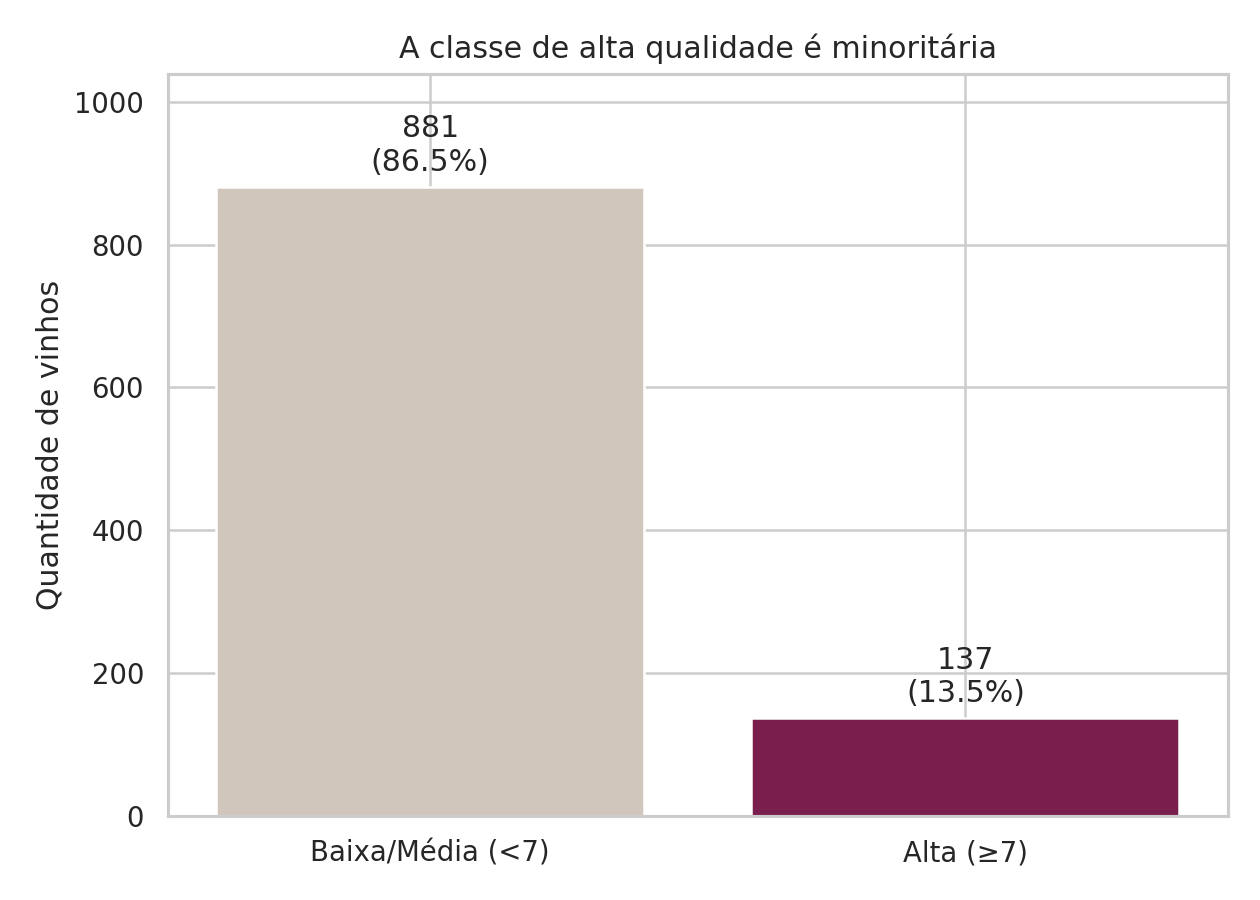

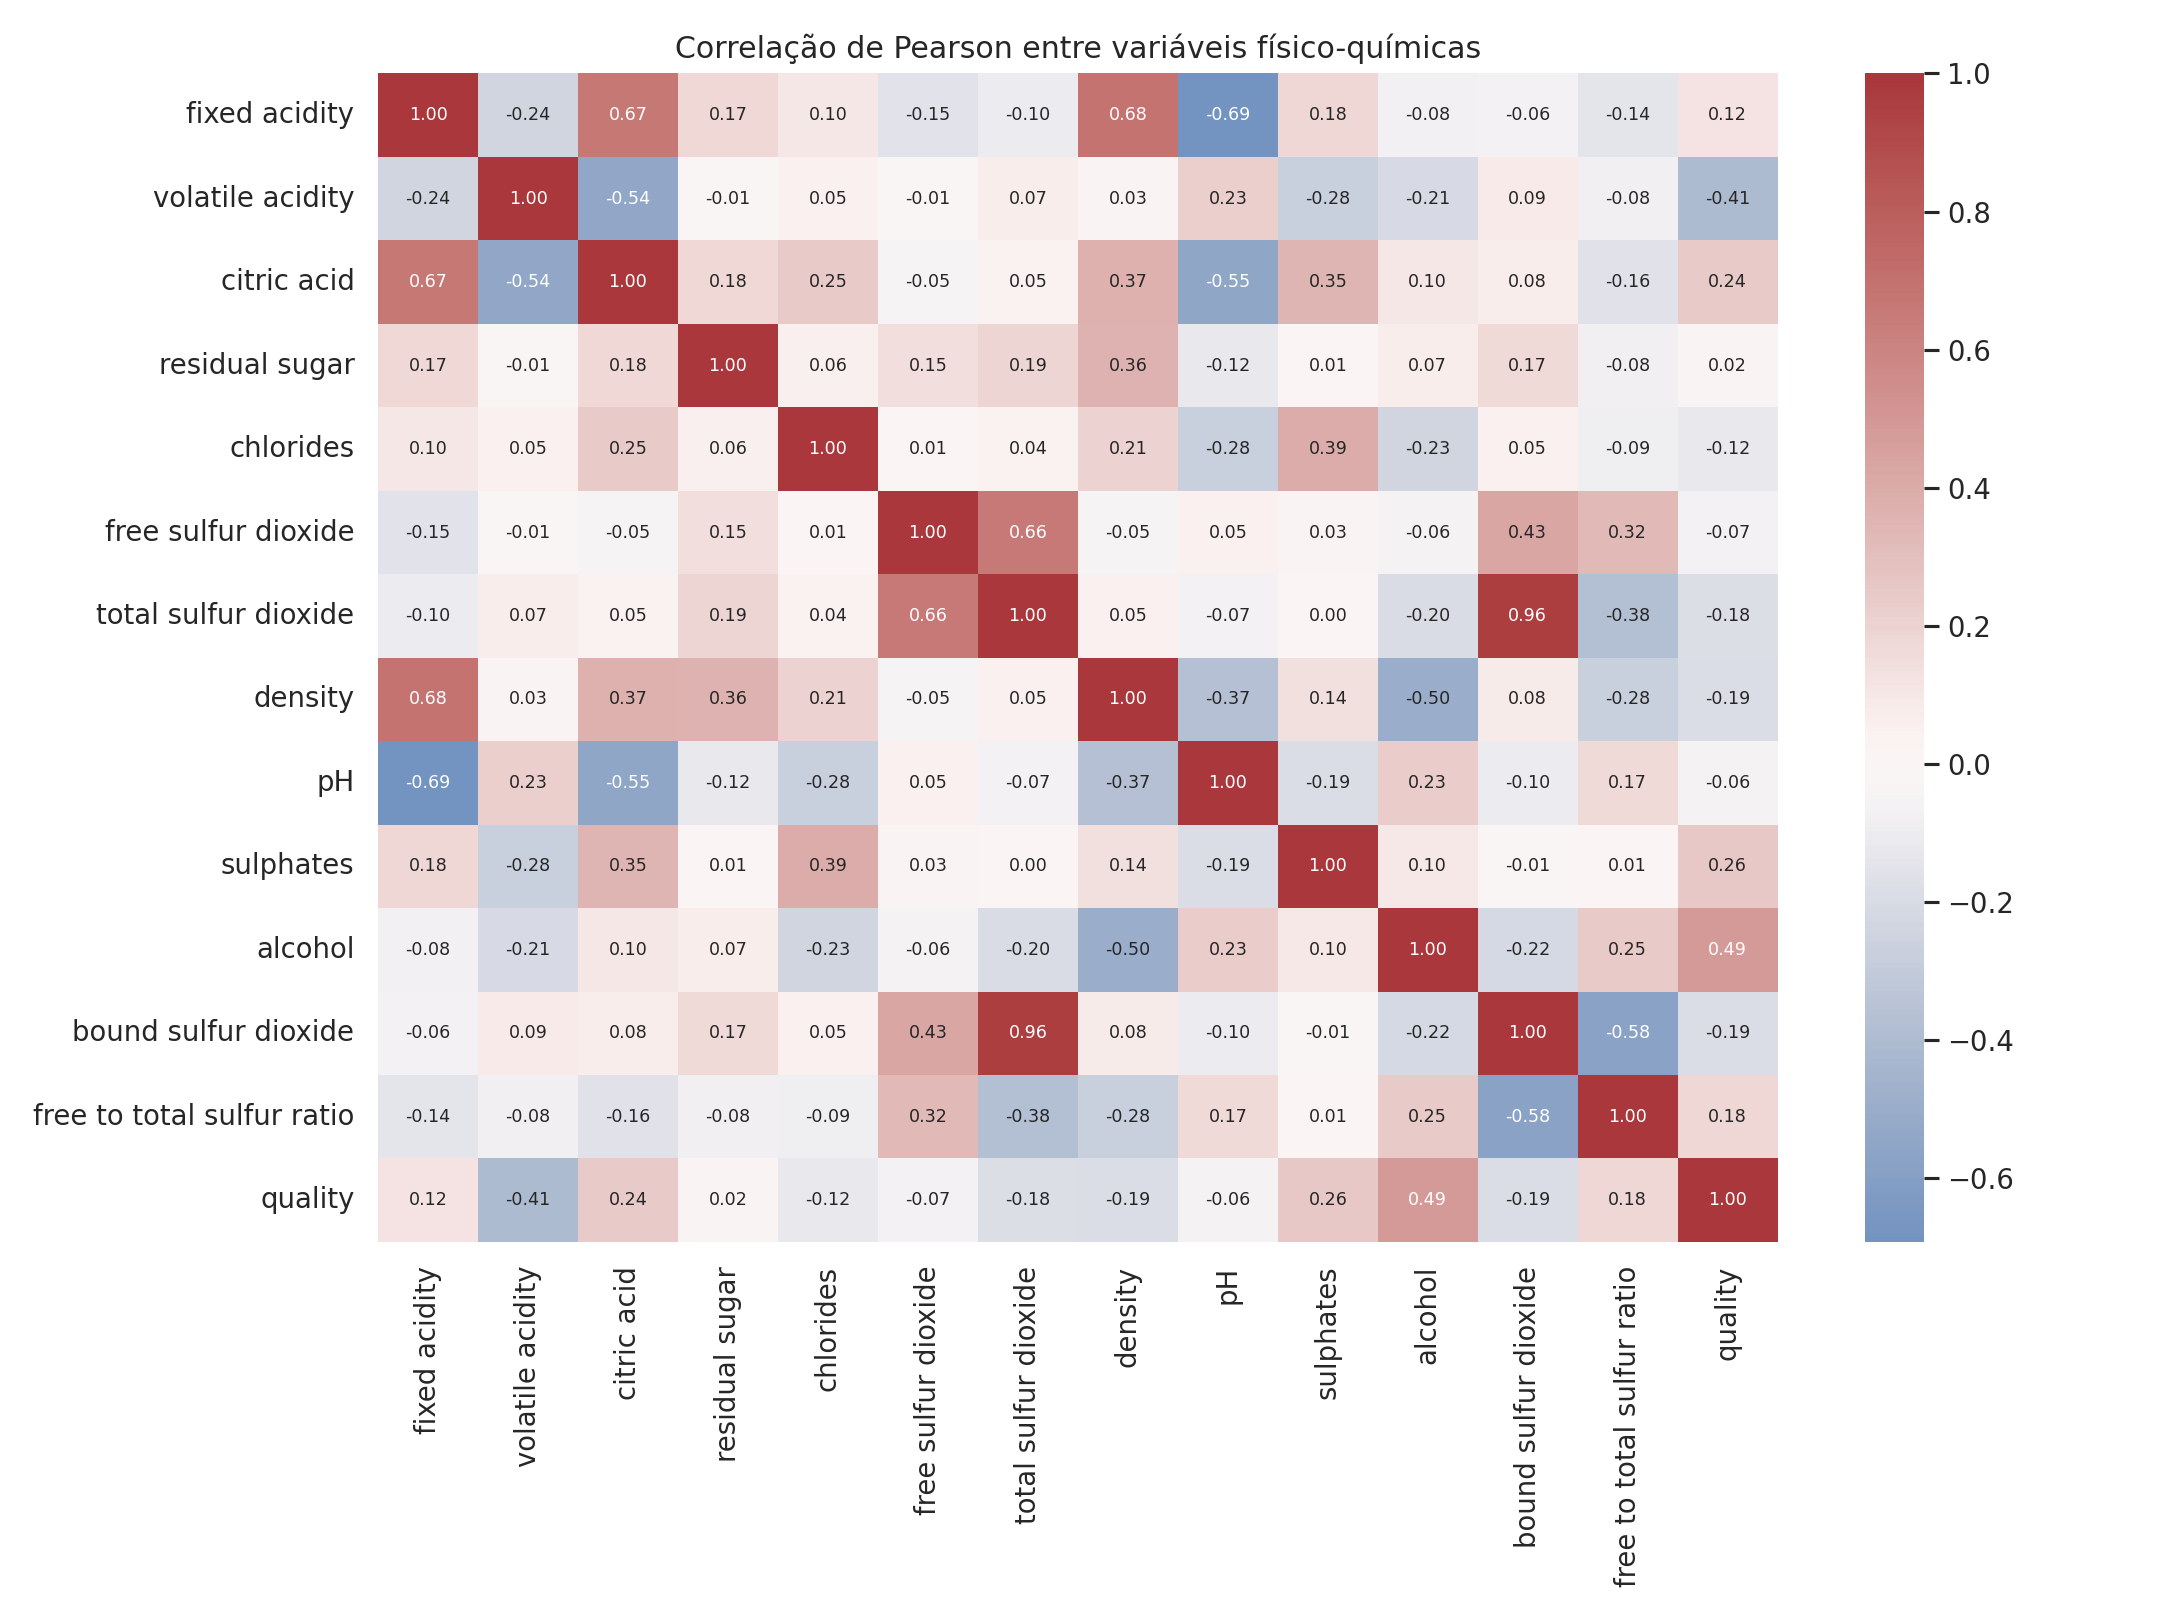

,feature,lower_bound,upper_bound,outlier_count,outlier_share
0,residual sugar,0.85000,3.65000,95,0.093320
1,chlorides,0.04000,0.12000,71,0.069745
2,sulphates,0.29500,0.97500,41,0.040275
3,fixed acidity,4.10000,12.10000,37,0.036346
4,total sulfur dioxide,-40.50000,123.50000,33,0.032417
5,density,0.99219,1.00121,30,0.029470
6,pH,2.92500,3.68500,24,0.023576
7,free sulfur dioxide,-14.00000,42.00000,16,0.015717
8,volatile acidity,0.00750,1.02750,10,0.009823
9,alcohol,6.95000,13.75000,6,0.005894


In [3]:
X, y, eda = create_eda()
display(Image(filename=str(RESULTS / 'class_distribution.png'), width=650))
display(Image(filename=str(RESULTS / 'correlation_heatmap.png'), width=850))
display(pd.read_csv(RESULTS / 'outlier_summary.csv'))

### Leitura das correlações

- Álcool apresenta a associação positiva mais forte com alta qualidade.
- Acidez volátil apresenta associação negativa.
- Acidez fixa se relaciona negativamente com pH e positivamente com densidade/ácido cítrico.
- SO₂ livre e total variam juntos porque o livre compõe o total.
- Densidade e álcool variam em sentidos opostos, coerente com o processo de fermentação.

## 3. Pré-processamento e engenharia de atributos

São criados `bound sulfur dioxide = total - free` e `free to total sulfur ratio`. A Regressão Logística e o SVM recebem padronização com `StandardScaler` dentro do pipeline, evitando vazamento. O Random Forest não exige escala. Todos os modelos tratam o desbalanceamento por pesos de classe.

## 4. Modelagem e avaliação

Comparamos Regressão Logística, Random Forest e SVM RBF. A seleção usa PR-AUC em validação cruzada estratificada de cinco folds. O limiar que maximiza F1 é estimado com previsões out-of-fold apenas do treino.

,model,cv_pr_auc,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,best_params
0,Random Forest,0.590316,0.206667,0.882353,0.885122,0.533333,0.888889,0.666667,0.914208,0.696937,"{""model__max_depth"": null, ""model__max_features"": ""sqrt"", ""model__min_samples_leaf"": 1, ""model__n_estimators"": 600}"
1,SVM RBF,0.580793,0.285798,0.852941,0.758318,0.459459,0.629630,0.531250,0.895585,0.540461,"{""model__C"": 0.25, ""model__gamma"": 0.03}"
2,Logistic Regression,0.569943,0.660814,0.838235,0.749843,0.425000,0.629630,0.507463,0.887424,0.489103,"{""model__C"": 0.05}"


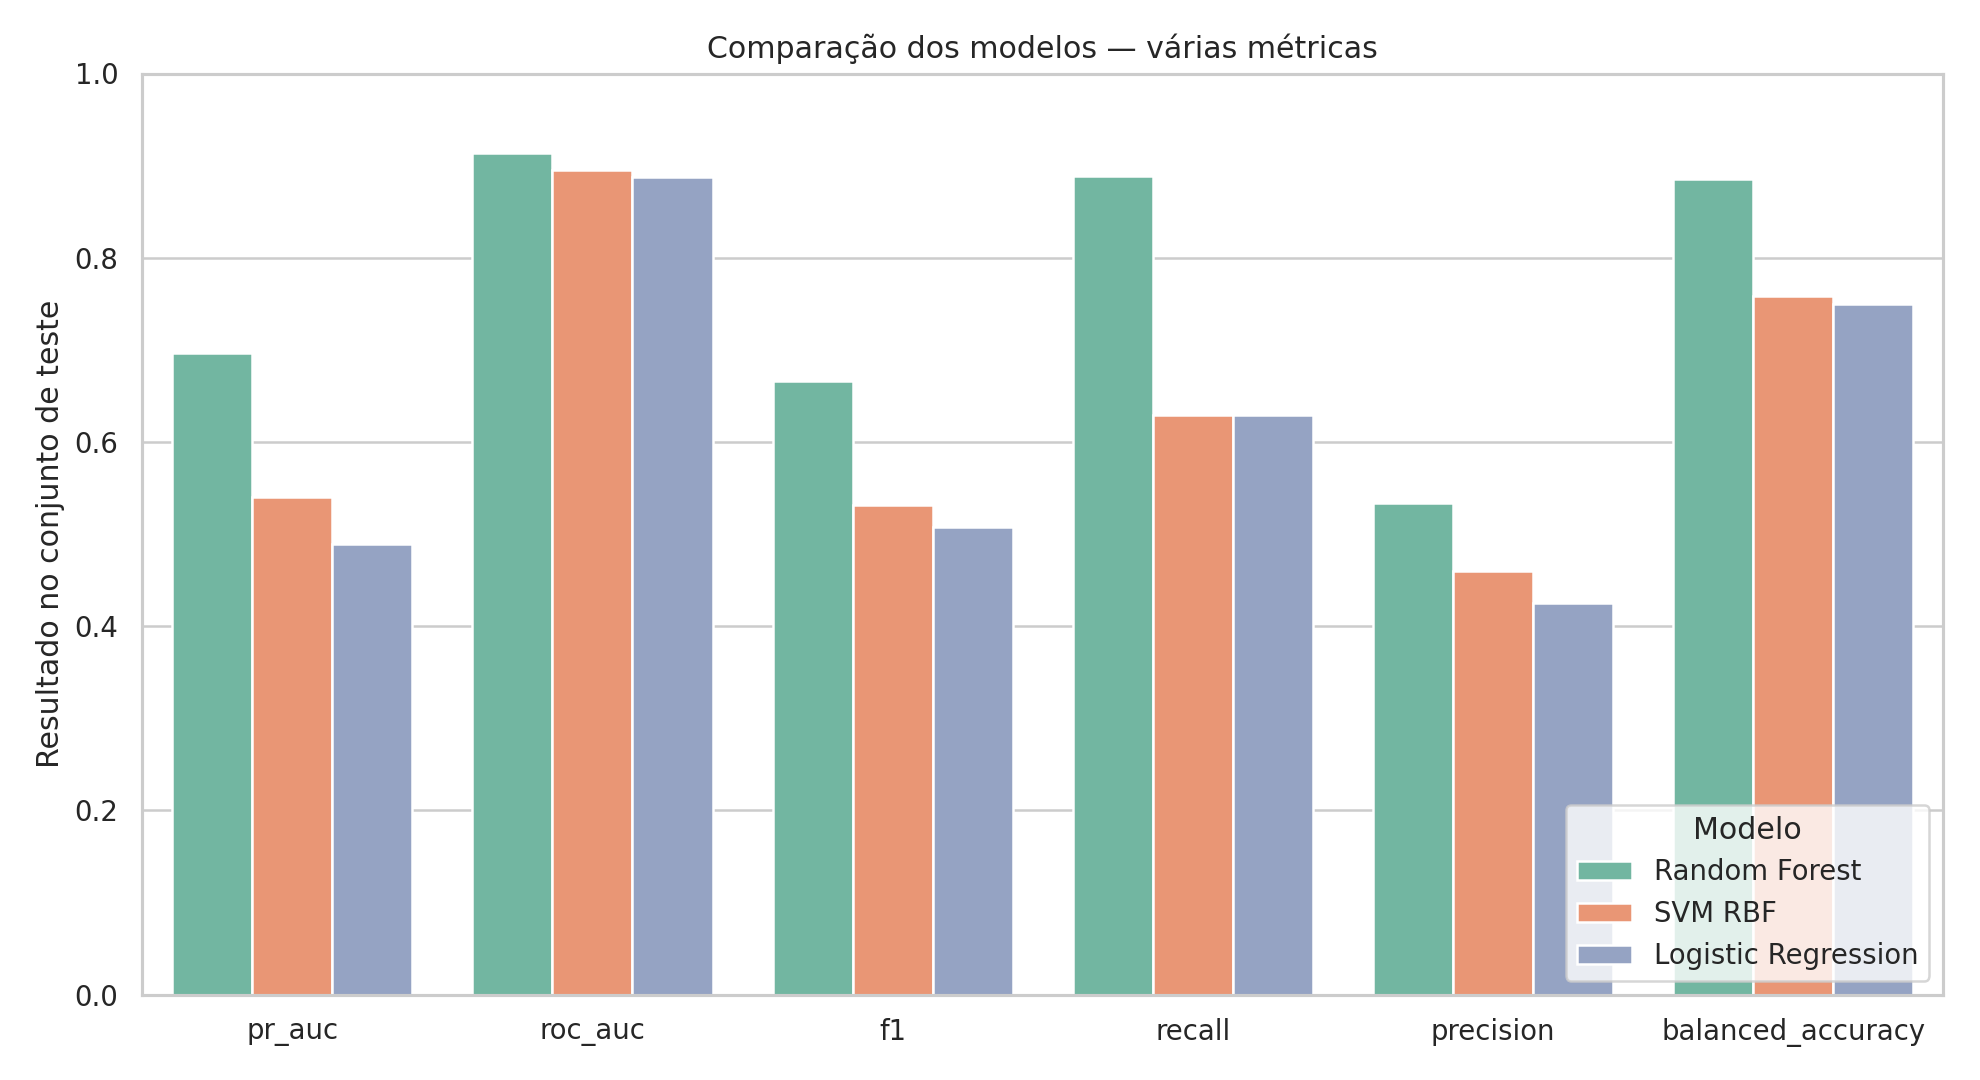

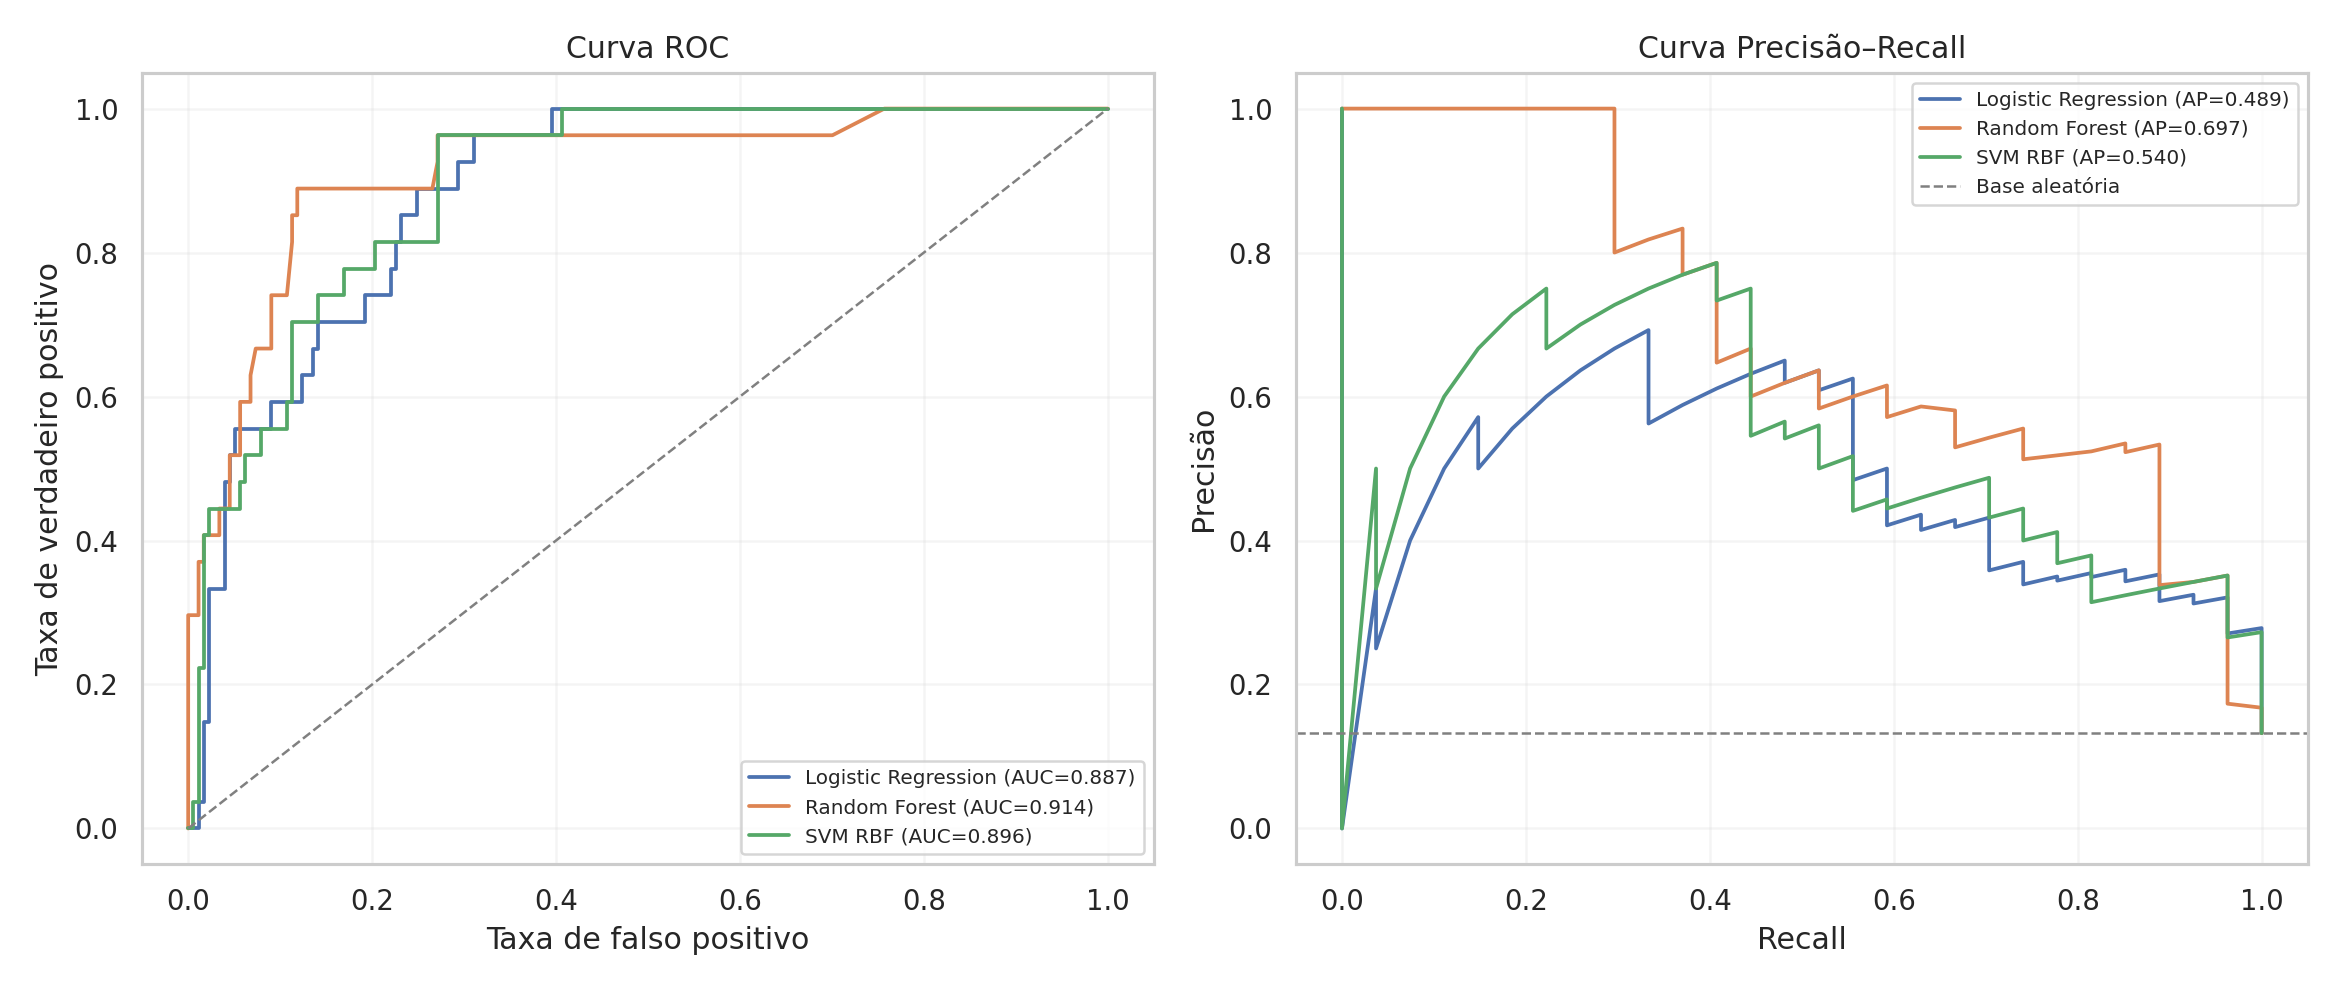

Modelo vencedor: Random Forest


In [4]:
# Esta célula pode levar alguns minutos.
metrics, importance, best_model = train_and_evaluate(X, y, RESULTS)
display(metrics)
print('Modelo vencedor:', best_model)
display(Image(filename=str(RESULTS / 'model_comparison.png'), width=900))
display(Image(filename=str(RESULTS / 'roc_pr_curves.png'), width=1000))

## 5. Interpretação e implicações

O Random Forest oferece o melhor PR-AUC no teste. Seu limiar prioriza recall, adequado a uma triagem em que perder um lote potencialmente premium é mais custoso do que encaminhar uma amostra comum para avaliação. Sulfatos, álcool e acidez volátil lideram a importância por permutação.

**Implicação:** o modelo deve priorizar lotes para avaliação sensorial e revisão de processo. Não deve prescrever alterações químicas isoladas nem substituir o enólogo.

,feature,importance_mean,importance_std
0,sulphates,0.136564,0.049932
1,alcohol,0.126492,0.049900
2,volatile acidity,0.065864,0.049961
3,citric acid,0.036835,0.027637
4,density,0.020596,0.016943
5,fixed acidity,0.020329,0.011712
6,pH,0.012746,0.014200
7,free to total sulfur ratio,0.008271,0.019908
8,total sulfur dioxide,0.007265,0.020540
9,bound sulfur dioxide,0.002083,0.018693


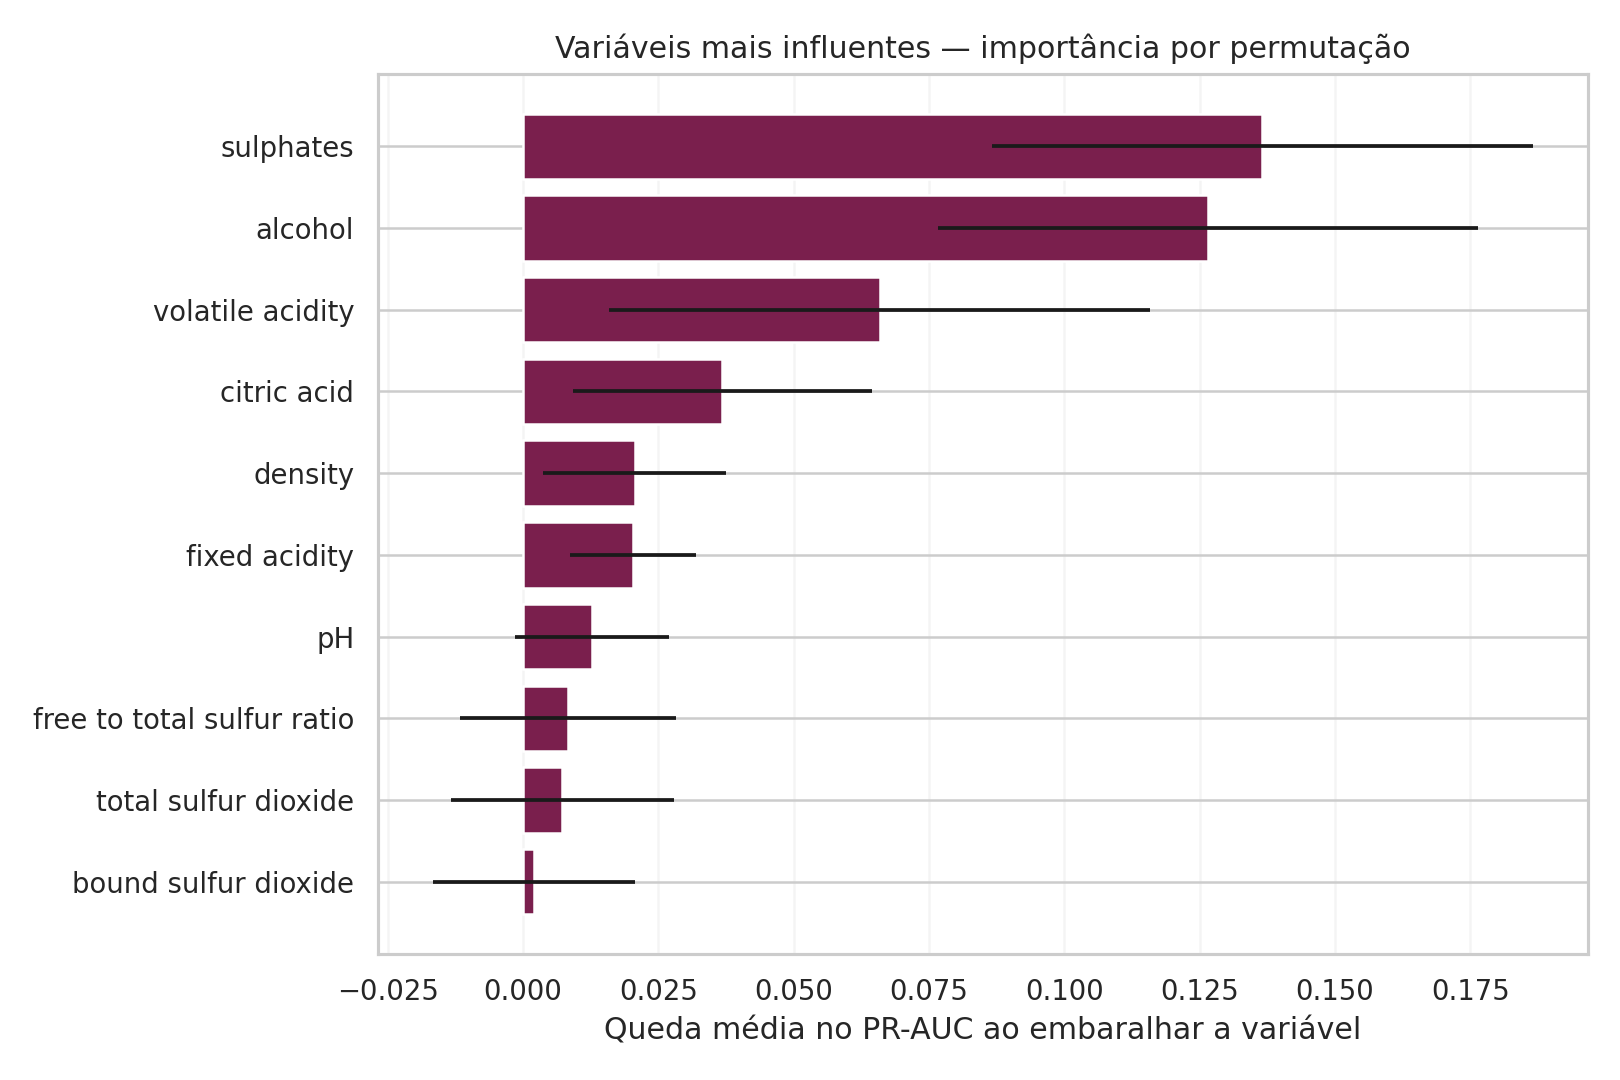

,model,cv_pr_auc,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,best_params
0,Random Forest,0.590316,0.206667,0.882353,0.885122,0.533333,0.888889,0.666667,0.914208,0.696937,"{""model__max_depth"": null, ""model__max_features"": ""sqrt"", ""model__min_samples_leaf"": 1, ""model__n_estimators"": 600}"
1,SVM RBF,0.580793,0.285798,0.852941,0.758318,0.459459,0.629630,0.531250,0.895585,0.540461,"{""model__C"": 0.25, ""model__gamma"": 0.03}"
2,Logistic Regression,0.569943,0.660814,0.838235,0.749843,0.425000,0.629630,0.507463,0.887424,0.489103,"{""model__C"": 0.05}"


In [5]:
display(pd.read_csv(RESULTS / 'feature_importance.csv').head(10))
display(Image(filename=str(RESULTS / 'feature_importance.png'), width=800))
display(pd.read_csv(RESULTS / 'model_metrics.csv'))

## 6. Limitações e próximos passos

A base é pequena, desbalanceada, restrita a vinhos tintos Vinho Verde e não inclui safra, uva, preço ou condições do processo. É necessário validar o modelo em novos lotes, monitorar mudança de perfil e calibrar o limiar com custos reais de negócio.